In [1]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn import datasets
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
db = datasets.load_diabetes()
X=db.data
y=db.target
print(X.shape)
print(type(X))
print(y.shape)
print(db.DESCR)

(442, 10)
<class 'numpy.ndarray'>
(442,)
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Ea

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [4]:
print(X_train.shape)
print(X[0:5,0:5])
print(y[0:5])

(309, 10)
[[ 0.03807591  0.05068012  0.06169621  0.02187239 -0.0442235 ]
 [-0.00188202 -0.04464164 -0.05147406 -0.02632753 -0.00844872]
 [ 0.08529891  0.05068012  0.04445121 -0.00567042 -0.04559945]
 [-0.08906294 -0.04464164 -0.01159501 -0.03665608  0.01219057]
 [ 0.00538306 -0.04464164 -0.03638469  0.02187239  0.00393485]]
[151.  75. 141. 206. 135.]


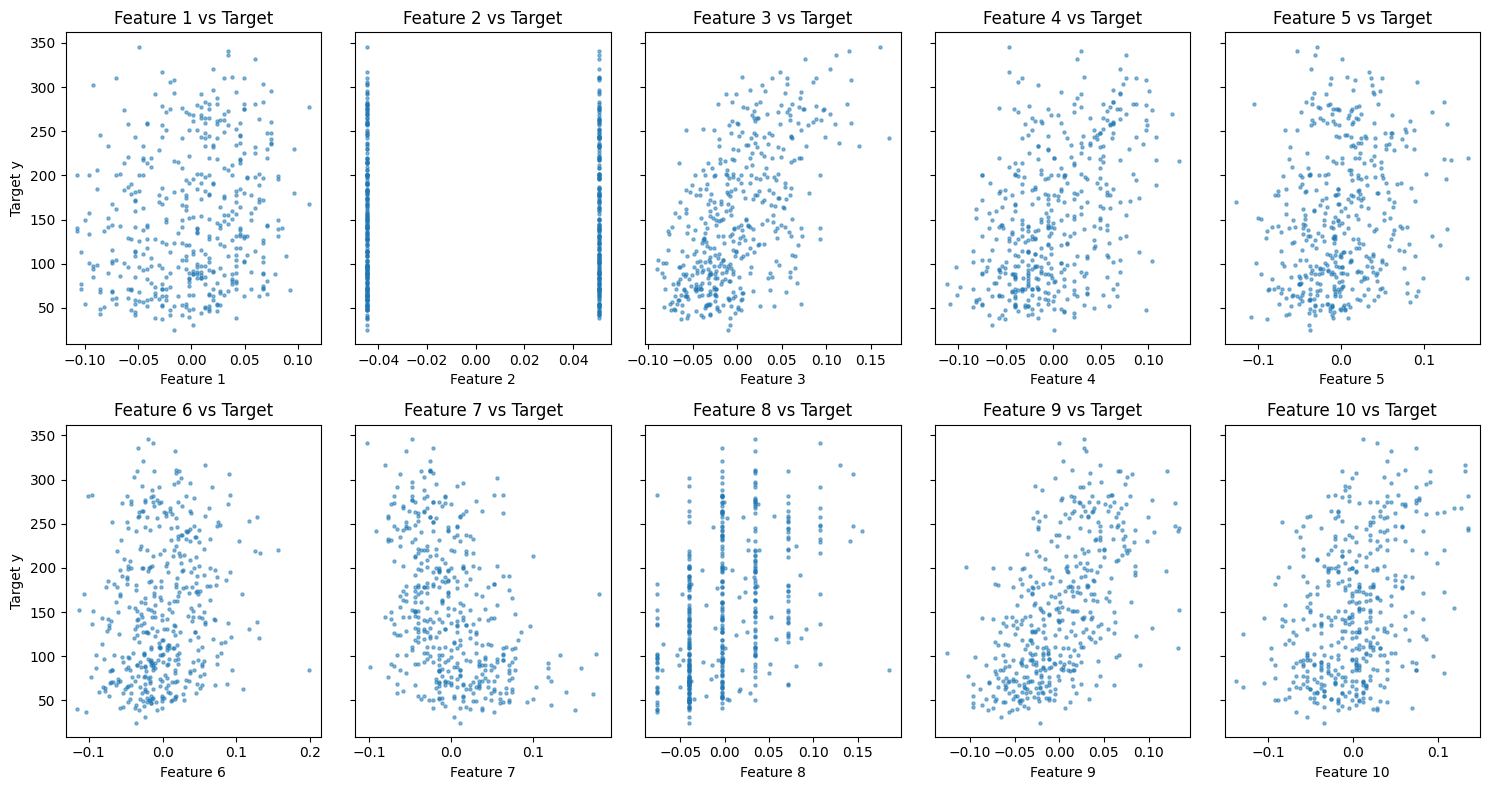

In [5]:
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8), sharey=True)
axes = axes.flatten()
for i in range(10):
    axes[i].scatter(X[:, i], y, alpha=0.5, s=5)
    axes[i].set_title(f"Feature {i+1} vs Target")
    axes[i].set_xlabel(f"Feature {i+1}")
    if i % 5 == 0:
        axes[i].set_ylabel("Target y")
        
plt.tight_layout()
plt.show()        

In [6]:
model=LinearRegression()
print(model)
model.fit(X_train, y_train)

LinearRegression()


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_pred=model.predict(X_test)
print(y_pred)

[138.46970031 181.10052342 125.34400904 292.75977277 123.8830531
  91.89830434 257.26463123 177.76169318  84.98549706 109.15960992
  94.4855284  166.13235108  57.40742502 206.13897354  97.7811842
 131.00472765 214.29789972 252.52907661 199.66656381 219.49985634
 203.23671317  88.00656925  70.65108459 186.92233427 155.81266751
 162.81022205 191.93135706 184.72924276  46.62920829 108.26566599
 178.14743952  91.35065005 127.72125745 184.04205666 172.23799897
 189.51548863 121.83265708 117.75339206 145.67950306  58.57563401
  72.55421321 107.27571105 166.15280313 153.29339984 165.19282154
  62.95752038  73.58909449 110.05656189  54.49723354 164.88920632
 152.49472803  63.8874565  111.4354561  108.34936269 179.96973311
 158.70054112  95.04833555 209.68990406 118.37356519  69.69946093
 189.04680627 204.99138626 140.26840176 105.75963198 131.22316354
 201.65649349 173.60251683 164.25810664 122.01567481 143.53425629
 179.42286037 201.32086534 234.50804093 146.96093984  80.27567403
 160.8682217

In [8]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Squared Error: 2821.7509810013107
R-squared: 0.4772897164322617


In [9]:
print("Model Coefficients:", model.coef_)
print("Model Intercept:", model.intercept_)

Model Coefficients: [  29.25401303 -261.7064691   546.29972304  388.39834056 -901.95966819
  506.76324136  121.15435079  288.03526689  659.26895081   41.37670105]
Model Intercept: 151.00821291456543


In [10]:
print(f"Number of test points: {len(X_test)}")
print(f"Number of predictions: {len(y_pred)}")

diff = y_test - y_pred
print(len(diff))
print(np.count_nonzero(diff))
zero_count = len(diff)-np.count_nonzero(diff)
print(f"Number of exact predictions (diff = 0): {zero_count}")

Number of test points: 133
Number of predictions: 133
133
133
Number of exact predictions (diff = 0): 0
